# Early Warning Signals

As proposed by Gidea & Katz, we are going to calculate the $L^1$ and $L^2$ norms of the persistence landscape and their spectral density at low frequencies.

## Persistence Landscape

Persistence landscapes have many advantages over persistence diagrams; one of them is that they are continuous functions and still related to persistence diagrams. It transforms birth and death to a continuous function of this form:
$$\lambda_k(t) = k\text{-th largest value of } \min(t - b, d - t)_+$$
where $(b,d)$ are birth-death pairs and $(\cdot)_+$​ denotes the positive part, i.e., $\max(\cdot, 0)$.

## $L^p$-norms

We quantify the temporal changes in persistence landscapes via their $L^p$-norms. Gidea & Katz find that, in the vicinity of financial meltdowns, the $L^p$-norms show strong growth prior to the primary peak, which ascends during a crash. 

The $L^p$ norm of a persistence landscape $\lambda = \{\lambda_k\}_{k=1}^{\infty}$ is defined as:

$$\|\lambda\|_p = \left(\sum_{k=1}^{\infty} \int_{-\infty}^{\infty} |\lambda_k(t)|^p \, dt\right)^{1/p}$$

where $\lambda_k : \mathbb{R} \rightarrow \mathbb{R}$ are the persistence landscape functions and $p \geq 1$. For $p=1$ this gives the $L^1$ norm and for $p=2$ the $L^2$ norm.

In [6]:
import pickle
import numpy as np
import pandas as pd

# Load market returns and persistence diagrams
market_returns = pd.read_csv("../data/market_returns.csv", index_col=0, parse_dates=True)

with open("../data/persistence_diagrams.pkl", "rb") as f:
    persistence_diagrams = pickle.load(f)

# Verify data loaded correctly
print(len(persistence_diagrams))
print(market_returns.shape)

6242
(6291, 4)


In [7]:
from persim import PersistenceLandscaper

# Example: persistence landscape for a calm period window
calm_results = persistence_diagrams[market_returns.index.get_loc("2005-01-03")]

pl = PersistenceLandscaper()
landscape = pl.fit_transform([calm_results[1]])

print(type(landscape))
print(landscape)

<class 'numpy.ndarray'>
[[0.00000000e+00 9.62156164e-06 1.92431233e-05 ... 1.92431233e-05
  9.62156164e-06 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
  0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
  0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
  0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
  0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
  0.00000000e+00 0.00000000e+00]]


### Setting the Landscape Grid

`PersistenceLandscaper` requires a fixed grid to discretize the landscape functions. We set the grid using the global minimum birth and maximum death values across all H1 diagrams, ensuring no features fall outside the grid and produce empty landscapes.

In [8]:
# Persistence diagrams global min and max for H1
all_h1 = [persistence_diagrams[i][1] for i in range(len(persistence_diagrams)) 
          if len(persistence_diagrams[i][1]) > 0]

global_min = min(d[:, 0].min() for d in all_h1)
global_max = max(d[:, 1].max() for d in all_h1)

print(global_min, global_max)

0.0019034252036362886 0.044512998312711716


In [9]:
# Persistence landscapes parameters
pl = PersistenceLandscaper(start=global_min, stop=global_max, num_steps=500)

## Computing $L^p$ Norms
We compute the $L^1$ and $L^2$ norms for each window's persistence landscape across the full 1997-2021 period.

In [10]:
import matplotlib.pyplot as plt

# Compute L² norms of persistence landscapes for all windows
l2_norms = []
for i in range(len(persistence_diagrams)):
    try:
        landscape = pl.fit_transform([persistence_diagrams[i][1]])
        l2_norms.append(np.linalg.norm(landscape, ord=2))
    except:
        l2_norms.append(0.0)

# Min-max normalization to [0, 1]
normalized_l2 = (pd.Series(l2_norms, index=market_returns.index[49:]) - min(l2_norms)) / (max(l2_norms) - min(l2_norms))

Bad choice of grid, values is empty
Bad choice of grid, values is empty
Bad choice of grid, values is empty
Bad choice of grid, values is empty


We normalize both norms to $[0,1]$ to make them comparable and plot them as a time series.

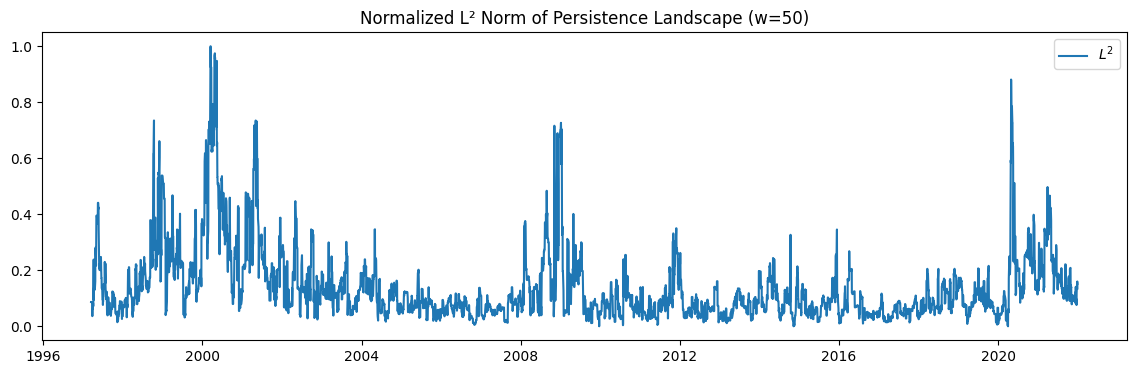

In [11]:
# Plot the normalized L² norms
plt.figure(figsize=(14, 4))
plt.plot(normalized_l2, label=r"$L^2$")
plt.title("Normalized L² Norm of Persistence Landscape (w=50)")
plt.legend()
plt.show()

In [12]:
# Compute L¹ norms of persistence landscapes for all windows
l1_norms = []
for i in range(len(persistence_diagrams)):
    try:
        landscape = pl.fit_transform([persistence_diagrams[i][1]])
        l1_norms.append(np.linalg.norm(landscape, ord=1))
    except:
        l1_norms.append(0.0)

# Min-max normalization to [0, 1]
normalized_l1 = (pd.Series(l1_norms, index=market_returns.index[49:]) - min(l1_norms)) / (max(l1_norms) - min(l1_norms))


Bad choice of grid, values is empty
Bad choice of grid, values is empty
Bad choice of grid, values is empty
Bad choice of grid, values is empty


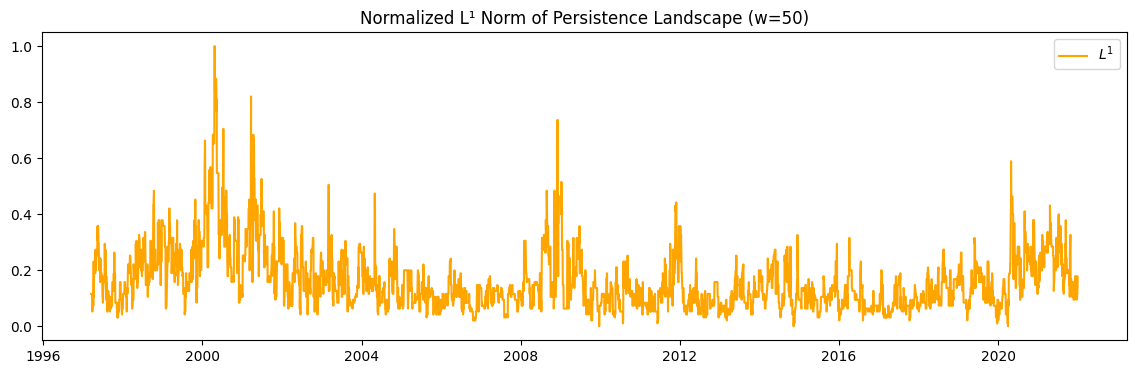

In [20]:
# Plot the normalized L¹ norms
plt.figure(figsize=(14, 4))
plt.plot(normalized_l1, label=r"$L^1$", color='orange')
plt.title("Normalized L¹ Norm of Persistence Landscape (w=50)")
plt.legend()
plt.show()

### $L^1$ and $L^2$ Norms
We plot both norms together to replicate Figure 9 from Gidea & Katz.

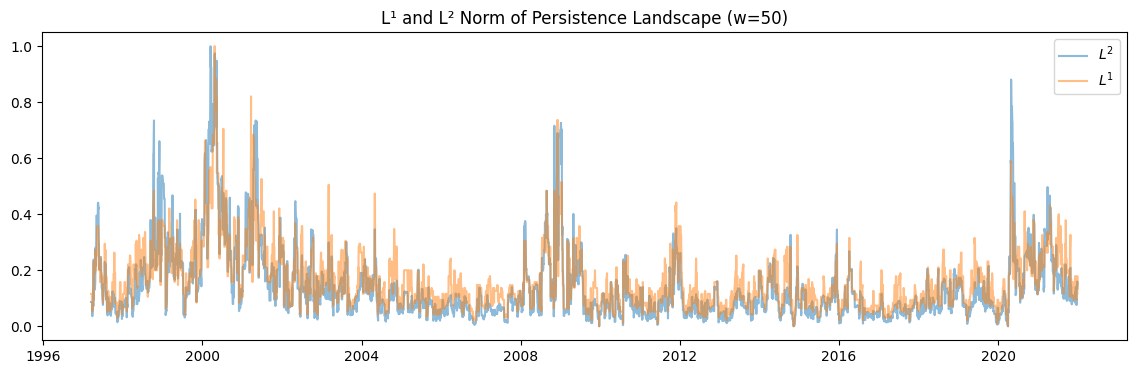

In [21]:
plt.figure(figsize=(14, 4))
plt.plot(normalized_l2, alpha=0.5, label=r"$L^2$")
plt.plot(normalized_l1, alpha=0.5, label=r"$L^1$")
plt.title("L¹ and L² Norm of Persistence Landscape (w=50)")
plt.legend()
plt.show()

### Dot-com Crash (1997-2001)
The signal begins rising in late 1999 and peaks around March-May 2000, coinciding with the NASDAQ peak. This is consistent with Gidea & Katz's finding of elevated topological activity prior to the crash.

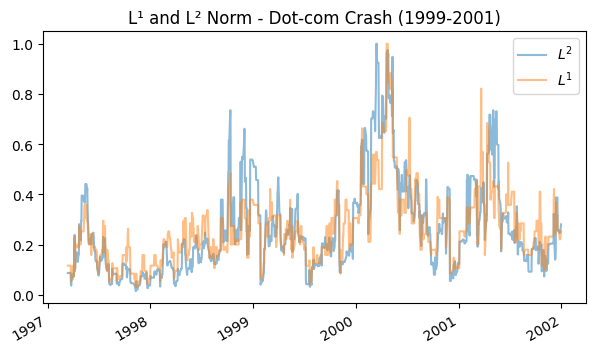

In [15]:
normalized_l2['1997':'2001'].plot(figsize=(7, 4), label=r"$L^2$", alpha=0.5)
normalized_l1['1997':'2001'].plot(label=r"$L^1$", alpha=0.5)
plt.title("L¹ and L² Norm - Dot-com Crash (1999-2001)")
plt.legend()
plt.show()

### Financial Crisis (2007-2009)
The signal builds gradually through 2007-2008 before Lehman's collapse in September 2008, suggesting early topological warning months before the peak crash.

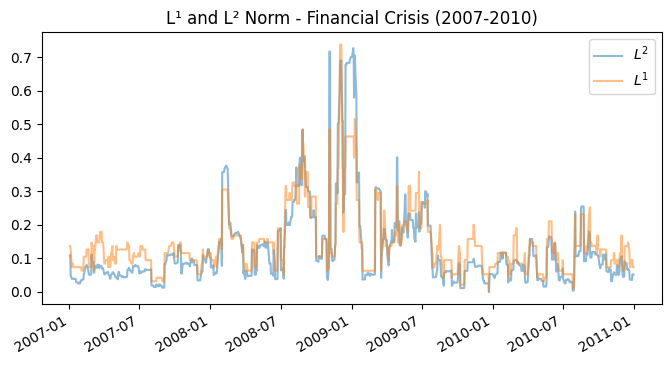

In [16]:
normalized_l2.loc['2007-01-01':'2010-12-31'].plot(figsize=(8, 4), label=r"$L^2$", alpha=0.5)
normalized_l1.loc['2007-01-01':'2010-12-31'].plot(label=r"$L^1$", alpha=0.5)
plt.title("L¹ and L² Norm - Financial Crisis (2007-2010)")
plt.legend()
plt.show()

### COVID Crash (2020)
Unlike the previous crises, the signal spikes sharply and suddenly in March-May 2020 with no prior buildup. This reflects the exogenous nature of the shock — COVID was not a structural market failure but an external event.

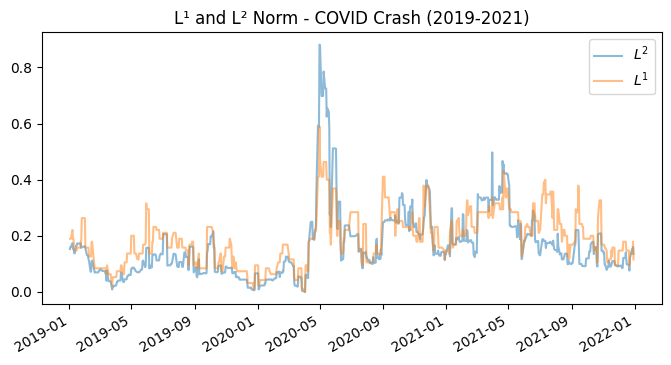

In [17]:
normalized_l2.loc['2019-01-01':'2021-12-31'].plot(figsize=(8, 4), label=r"$L^2$", alpha=0.5)
normalized_l1.loc['2019-01-01':'2021-12-31'].plot(label=r"$L^1$", alpha=0.5)
plt.title("L¹ and L² Norm - COVID Crash (2019-2021)")
plt.legend()
plt.show()

## Scpectral Density



In [18]:
spectral_density = []
for i in range(250, len(normalized_l2)):
    window = normalized_l2.iloc[i-250:i]
    fft = np.fft.fft(window)
    power = np.abs(fft) ** 2
    spectral_density.append(power[1:11].mean())

print(len(spectral_density))

5992


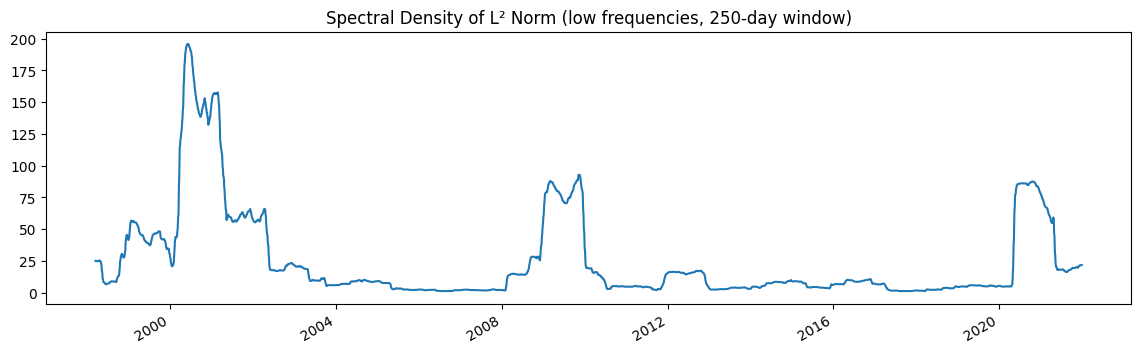

In [ ]:
spectral_l2 = pd.Series(spectral_density, index=normalized_l2.index[250:])
spectral_l2.plot(figsize=(14, 4), title="Spectral Density of L² Norm (low frequencies, 250-day window)")
plt.show()

In [22]:
spectral_density_l1 = []
for i in range(250, len(normalized_l1)):
    window = normalized_l1.iloc[i-250:i]
    fft = np.fft.fft(window)
    power = np.abs(fft) ** 2
    spectral_density_l1.append(power[1:11].mean())

print(len(spectral_density_l1))

5992


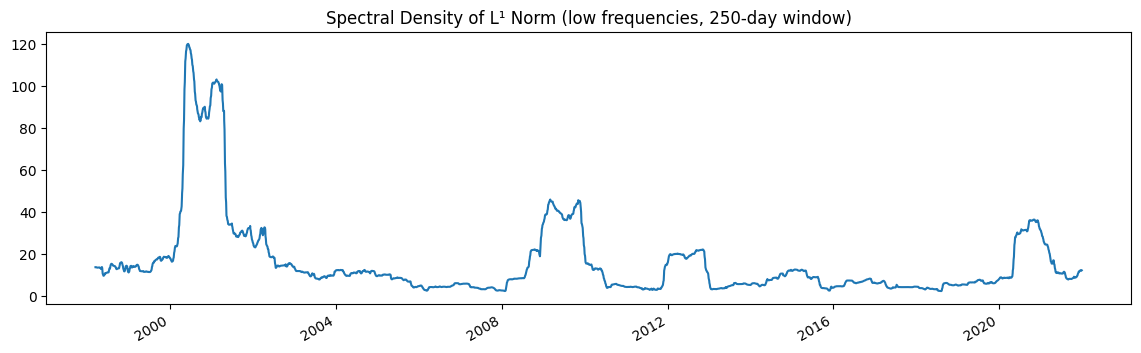

In [23]:
spectral_l1 = pd.Series(spectral_density_l1, index=normalized_l1.index[250:])
spectral_l1.plot(figsize=(14, 4), title="Spectral Density of L¹ Norm (low frequencies, 250-day window)")
plt.show()

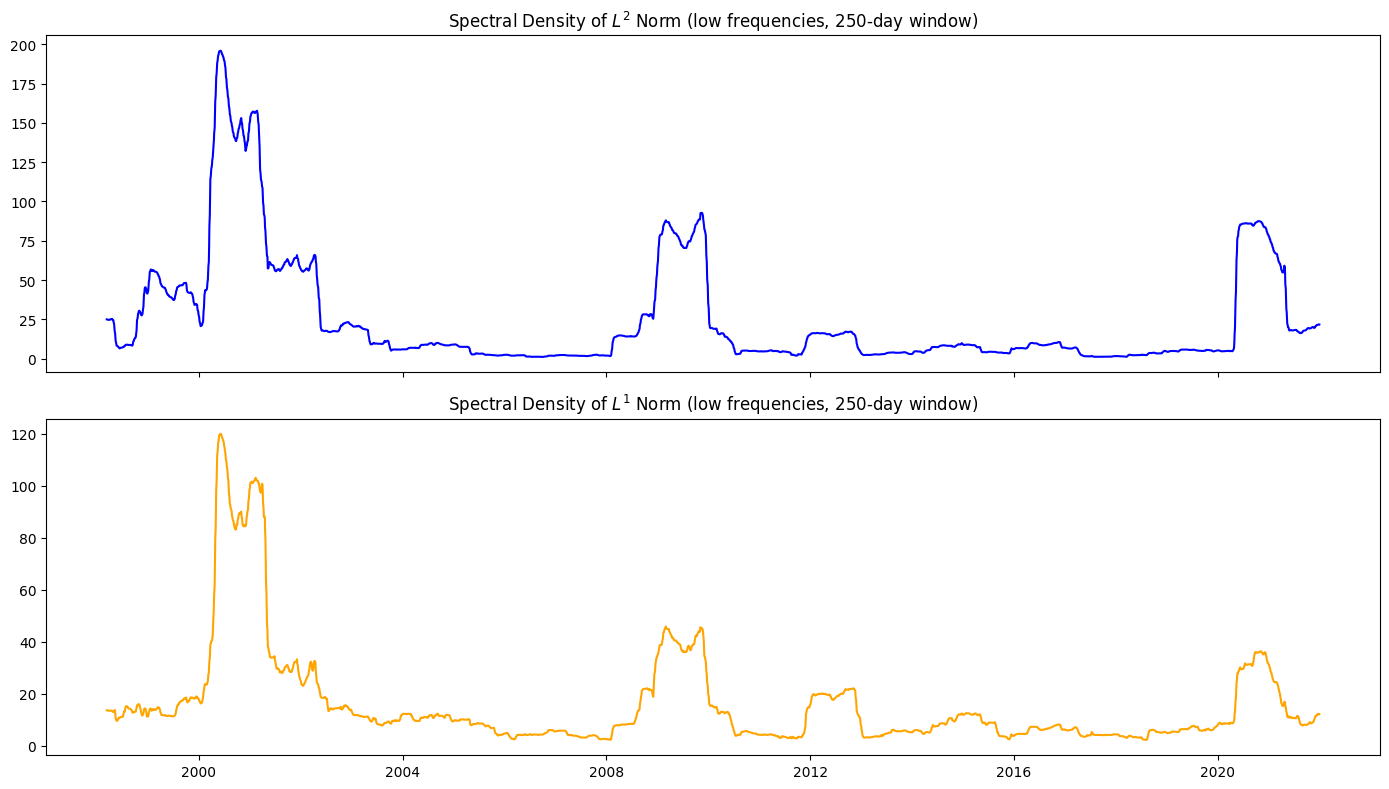

In [24]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(spectral_l2, color='blue')
axes[0].set_title(r"Spectral Density of $L^2$ Norm (low frequencies, 250-day window)")

axes[1].plot(spectral_l1, color='orange')
axes[1].set_title(r"Spectral Density of $L^1$ Norm (low frequencies, 250-day window)")

plt.tight_layout()
plt.show()